Ibuki Washburn

2026 年 3 月 23 日

Happy Customers

## Version of Packages

In [48]:
import sklearn
import statsmodels
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna

In [49]:
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("numpy:", np.__version__)
print("optuna:", optuna.__version__)

pandas: 2.2.2
scikit-learn: 1.5.1
statsmodels: 0.14.2
matplotlib: 3.8.4
numpy: 1.26.4
optuna: 4.1.0


## Basic EDA

In [50]:
import statsmodels.formula.api as smf
from pandas.plotting import scatter_matrix

In [51]:
Survey = pd.read_csv('C:/Users/Ibuki/Documents/Apziva/ACME-HappinessSurvey2020.csv')

In [52]:
Survey

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5
...,...,...,...,...,...,...,...
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5


**Data Description:**

Y = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers


X1 = my order was delivered on time


X2 = contents of my order was as I expected


X3 = I ordered everything I wanted to order


X4 = I paid a good price for my order


X5 = I am satisfied with my courier


X6 = the app makes ordering easy for me


Attributes X1 to X6 indicate the responses for each question and have values from 1 to 5 where the smaller number indicates less and the higher number indicates more towards the answer.



**Goal(s):**

Predict if a customer is happy or not based on the answers they give to questions asked.

Success Metrics:

Reach 73% accuracy score or above, or convince us why your solution is superior. We are definitely interested in every solution and insight you can provide us.

Try to submit your working solution as soon as possible. The sooner the better.

Bonus(es):

We are very interested in finding which questions/features are more important when predicting a customer’s happiness. Using a feature selection approach show us understand what is the minimal set of attributes/features that would preserve the most information about the problem while increasing predictability of the data we have. Is there any question that we can remove in our next survey?

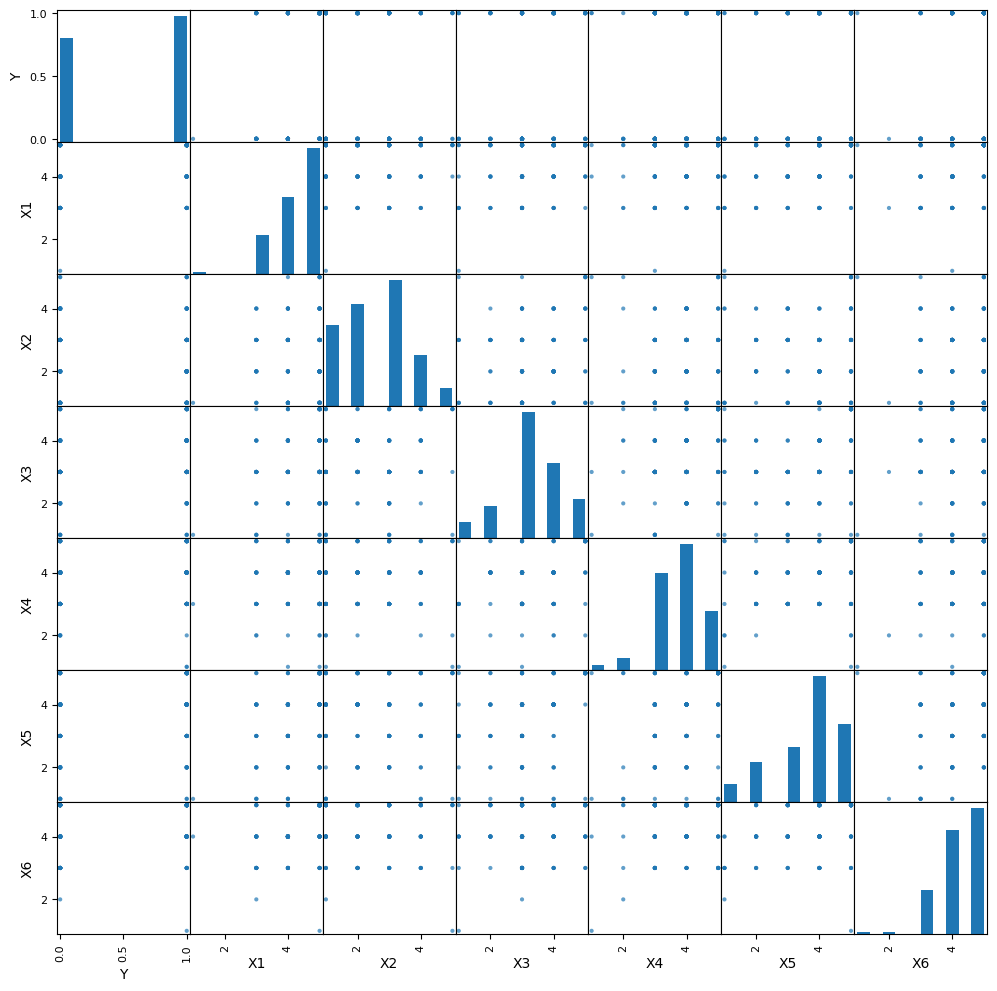

In [53]:
columns = ["Y","X1", "X2","X3","X4","X5","X6"]


scatter_matrix(Survey[columns], figsize=(12, 12), diagonal='hist', alpha=0.7)
plt.show()


In [54]:
correlation_matrix = Survey[columns].corr()


print(correlation_matrix)

           Y        X1        X2        X3        X4        X5        X6
Y   1.000000  0.280160 -0.024274  0.150838  0.064415  0.224522  0.167669
X1  0.280160  1.000000  0.059797  0.283358  0.087541  0.432772  0.411873
X2 -0.024274  0.059797  1.000000  0.184129  0.114838  0.039996 -0.062205
X3  0.150838  0.283358  0.184129  1.000000  0.302618  0.358397  0.203750
X4  0.064415  0.087541  0.114838  0.302618  1.000000  0.293115  0.215888
X5  0.224522  0.432772  0.039996  0.358397  0.293115  1.000000  0.320195
X6  0.167669  0.411873 -0.062205  0.203750  0.215888  0.320195  1.000000


In [55]:
cm = correlation_matrix.abs()
upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))

top_pairs = (upper.stack().sort_values(ascending=False).head(5))
print(top_pairs) # this is so we can see which interactions are the best to try, as there are too many variables to try every interaction combo.

X1  X5    0.432772
    X6    0.411873
X3  X5    0.358397
X5  X6    0.320195
X3  X4    0.302618
dtype: float64


In [56]:
logistic_model = smf.logit('Y ~ X1 + X2 + X3 +X4 + X5+ X6', data=Survey).fit() #basic look at the variables
logistic_model.summary()

Optimization terminated successfully.
         Current function value: 0.637875
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                  126
Model:                          Logit   Df Residuals:                      119
Method:                           MLE   Df Model:                            6
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.07367
Time:                        20:19:11   Log-Likelihood:                -80.372
converged:                       True   LL-Null:                       -86.764
Covariance Type:            nonrobust   LLR p-value:                   0.04660
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.5674      1.489     -2.396      0.017      -6.486      -0.649
X1             0.5738      0.289      1.987      0.047       0.008       1.140
X2            -0.0937      0.176     -0.533      0.594      -0.438       0.251
X3             0.1317      0.210      0.626      0.531      -0.280       0.544
X4            -0.0058      0.236     -0.025      0.980      -0.468       0.456
X5             0.2045      0.194      1.053      0.293      -0.176       0.585
X6             0.0830      0.264      0.314      0.753      -0.435       0.601
==============================================================================
"""

In [57]:
logistic_model = smf.logit('Y ~ X1 + X2 + X3 +X4 + X5+ X6 +          X1:X5+ X1:X6 + X3:X5 + X5:X6 + X3:X4 ', data=Survey).fit() #a look at all the vars and interactions
logistic_model.summary()

Optimization terminated successfully.
         Current function value: 0.595152
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                  126
Model:                          Logit   Df Residuals:                      114
Method:                           MLE   Df Model:                           11
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.1357
Time:                        20:19:11   Log-Likelihood:                -74.989
converged:                       True   LL-Null:                       -86.764
Covariance Type:            nonrobust   LLR p-value:                   0.01477
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -19.0716      8.601     -2.217      0.027     -35.928      -2.215
X1             5.6766      2.415      2.351      0.019       0.943      10.410
X2            -0.1378      0.189     -0.730      0.465      -0.508       0.232
X3            -0.6242      1.183     -0.528      0.598      -2.943       1.695
X4            -0.6268      0.842     -0.744      0.457      -2.277       1.023
X5            -2.3957      1.496     -1.601      0.109      -5.328       0.536
X6             5.3253      2.158      2.468      0.014       1.096       9.555
X1:X5          0.2711      0.247      1.096      0.273      -0.214       0.756
X1:X6         -1.3997      0.530     -2.639      0.008      -2.439      -0.360
X3:X5         -0.0062      0.197     -0.031      0.975      -0.392       0.379
X5:X6          0.3057      0.309      0.989      0.323      -0.300       0.912
X3:X4          0.1985      0.232      0.854      0.393      -0.257       0.654
==============================================================================
"""

In [58]:
logistic_model = smf.logit('Y ~ X1 + X5+ X6 +          X1:X6 + X5:X6 + X3:X4 ', data=Survey).fit() #reducing to only the msot significant ones based on p value
logistic_model.summary()

Optimization terminated successfully.
         Current function value: 0.607161
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                  126
Model:                          Logit   Df Residuals:                      119
Method:                           MLE   Df Model:                            6
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.1183
Time:                        20:19:12   Log-Likelihood:                -76.502
converged:                       True   LL-Null:                       -86.764
Covariance Type:            nonrobust   LLR p-value:                  0.002233
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -21.7515      8.321     -2.614      0.009     -38.060      -5.443
X1             6.0145      2.187      2.751      0.006       1.729      10.300
X5            -1.4329      1.138     -1.260      0.208      -3.663       0.797
X6             4.4178      1.995      2.215      0.027       0.509       8.327
X1:X6         -1.2665      0.501     -2.530      0.011      -2.248      -0.285
X5:X6          0.3593      0.269      1.333      0.182      -0.169       0.887
X3:X4          0.0218      0.041      0.536      0.592      -0.058       0.101
==============================================================================
"""

In [59]:
logistic_model = smf.logit('Y ~ X1   + X5+ X6 +       X1:X5+    X1:X6  ', data=Survey).fit() #reducing further based on p value 
logistic_model.summary()

Optimization terminated successfully.
         Current function value: 0.605811
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                  126
Model:                          Logit   Df Residuals:                      120
Method:                           MLE   Df Model:                            5
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.1202
Time:                        20:19:12   Log-Likelihood:                -76.332
converged:                       True   LL-Null:                       -86.764
Covariance Type:            nonrobust   LLR p-value:                 0.0008593
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -20.1370      8.371     -2.405      0.016     -36.545      -3.729
X1             4.3287      1.926      2.248      0.025       0.554       8.103
X5            -1.4910      0.914     -1.632      0.103      -3.282       0.300
X6             5.4000      2.155      2.505      0.012       1.176       9.624
X1:X5          0.3717      0.205      1.816      0.069      -0.030       0.773
X1:X6         -1.1769      0.478     -2.462      0.014      -2.114      -0.240
==============================================================================
"""

In [60]:
logistic_model = smf.logit('Y ~ X1  +   X6 +          X1:X5+ X1:X6  ', data=Survey).fit() #final reduction
logistic_model.summary()

Optimization terminated successfully.
         Current function value: 0.615996
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                  126
Model:                          Logit   Df Residuals:                      121
Method:                           MLE   Df Model:                            4
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.1054
Time:                        20:19:12   Log-Likelihood:                -77.615
converged:                       True   LL-Null:                       -86.764
Covariance Type:            nonrobust   LLR p-value:                  0.001079
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -19.7948      8.234     -2.404      0.016     -35.933      -3.657
X1             4.2587      1.879      2.266      0.023       0.576       7.942
X6             4.1927      1.939      2.162      0.031       0.392       7.994
X1:X5          0.0444      0.044      1.009      0.313      -0.042       0.131
X1:X6         -0.9124      0.427     -2.137      0.033      -1.749      -0.076
==============================================================================
"""

Since this is binary classification, F1 score is a good metric to see how well our models perform.

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

Precision is what proportion of the model's guesses are correct. Recall is what proportion of the global correct answers are correctly guessed by the model.

## Models

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB

import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression


In [62]:
Survey = pd.read_csv('C:/Users/Ibuki/Documents/Apziva/ACME-HappinessSurvey2020.csv')

In [63]:
import random


a = random.randint(1, 1530681)
print(a)


random.seed(a)
b = random.randint(1, 178042105)
print(b) # 92443420 was my b

1375789
92790282


In [64]:
random.seed(92443420) # 92443420 was my b

In [65]:
Xs = Survey.drop(columns=['Y'])
y = Survey['Y']

X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.15, random_state=  92443420)  # 92443420 was my b

#### Descision trees with optuna

In [66]:
# Descision trees with optuna

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 35)   # not sure the best range
    min_samples_split = trial.suggest_int('min_samples_split', 2, 35)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 15)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    
    model = DecisionTreeClassifier( criterion= criterion,
        max_depth=  max_depth,
        min_samples_split=  min_samples_split,
        min_samples_leaf=   min_samples_leaf,
        random_state = 92443420)
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

In [67]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials= 100)

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [68]:
#re assigning values:
params = study.best_params
print("Best params:", params)

final_model = DecisionTreeClassifier( criterion= params['criterion'],
    max_depth=         params['max_depth'],
    min_samples_split= params['min_samples_split'],
    min_samples_leaf=  params['min_samples_leaf'],
    random_state = 92443420)


final_model.fit(X_train, y_train) #retrain

Best params: {'max_depth': 26, 'min_samples_split': 20, 'min_samples_leaf': 9, 'criterion': 'gini'}


DecisionTreeClassifier(max_depth=26, min_samples_leaf=9, min_samples_split=20,
                       random_state=92443420)

In [69]:
y_pred = final_model.predict(X_test)

print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred)) 

F1: 0.782608695652174
              precision    recall  f1-score   support

           0       0.62      0.71      0.67         7
           1       0.82      0.75      0.78        12

    accuracy                           0.74        19
   macro avg       0.72      0.73      0.72        19
weighted avg       0.75      0.74      0.74        19



#### Random Forest with optuna

In [70]:
# Random Forest with optuna

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 2, 15)
    max_depth = trial.suggest_int('max_depth', 2, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 15)

    model = RandomForestClassifier( n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state = 92443420 )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

In [71]:
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=100)
params = study_rf.best_params
print("Best params:", params)

Best params: {'n_estimators': 5, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 7}


In [72]:
rf_model = RandomForestClassifier( n_estimators=  params['n_estimators'],
    max_depth=         params['max_depth'],
    min_samples_split= params['min_samples_split'],
    min_samples_leaf=  params['min_samples_leaf'],
    random_state = 92443420 )

rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

In [73]:
print(classification_report(y_test, rf_y_pred))
print("F1 Score:", f1_score(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       0.80      0.57      0.67         7
           1       0.79      0.92      0.85        12

    accuracy                           0.79        19
   macro avg       0.79      0.74      0.76        19
weighted avg       0.79      0.79      0.78        19

F1 Score: 0.8461538461538461


#### SVM with optuna: SVC with linear kernel

In [74]:
# SVM with optuna

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
def objective_svm(trial):
    C = trial.suggest_float('C', 0.01, 100, log=True)   
    gamma = trial.suggest_float('gamma', 0.0001, 1, log=True) 

    model = SVC(  # also SVC hyper param
        kernel='linear', #lifts lower to higher dimension
        C=C,
        gamma=gamma,
        random_state = 92443420 )

    
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    return f1_score(y_test, preds)




study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=100)

In [76]:
params = study_svm.best_params
print("Best params:", params)

Best params: {'C': 0.010189091613995989, 'gamma': 0.0046993446240563026}


In [77]:
svm_model = SVC( 
    kernel='linear',
    C=params['C'],
    gamma=params['gamma'],
    random_state = 92443420 )

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

In [78]:
print(classification_report(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.75      0.43      0.55         7
           1       0.73      0.92      0.81        12

    accuracy                           0.74        19
   macro avg       0.74      0.67      0.68        19
weighted avg       0.74      0.74      0.72        19

F1 Score: 0.8148148148148148


#### Gaussian Naive Bayes 

In [79]:
# Gaussian Naive Bayes 

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)  

In [80]:
print(classification_report(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))  

              precision    recall  f1-score   support

           0       0.50      0.71      0.59         7
           1       0.78      0.58      0.67        12

    accuracy                           0.63        19
   macro avg       0.64      0.65      0.63        19
weighted avg       0.68      0.63      0.64        19

F1 Score: 0.6666666666666666


#### Logistic Regression statsmodels

In [81]:
# Logistic Regression statsmodels  #can try sklearn

# redoing splitting for statsmodels 
Survey_train = X_train
Survey_train['Y'] = y_train

Survey_test = X_test
Survey_test['Y'] = y_test

In [82]:
logistic_model = smf.logit('Y ~ X1  +  X6 +          X1:X5+ X1:X6  ', data= Survey_train ).fit()
logistic_model.summary()

Optimization terminated successfully.
         Current function value: 0.627636
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                  107
Model:                          Logit   Df Residuals:                      102
Method:                           MLE   Df Model:                            4
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.09171
Time:                        20:19:18   Log-Likelihood:                -67.157
converged:                       True   LL-Null:                       -73.938
Covariance Type:            nonrobust   LLR p-value:                  0.008836
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.8317      8.524     -2.092      0.036     -34.538      -1.125
X1             4.0670      2.006      2.027      0.043       0.135       7.999
X6             3.5964      1.993      1.805      0.071      -0.309       7.502
X1:X5          0.0336      0.047      0.714      0.475      -0.059       0.126
X1:X6         -0.8293      0.451     -1.839      0.066      -1.713       0.054
==============================================================================
"""

In [83]:
y_probs = logistic_model.predict(Survey_test) 

y_pred = (y_probs >= 0.5).astype(int)

logistic_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                  107
Model:                          Logit   Df Residuals:                      102
Method:                           MLE   Df Model:                            4
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.09171
Time:                        20:19:18   Log-Likelihood:                -67.157
converged:                       True   LL-Null:                       -73.938
Covariance Type:            nonrobust   LLR p-value:                  0.008836
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.8317      8.524     -2.092      0.036     -34.538      -1.125
X1             4.0670      2.006      2.027      0.043       0.135       7.999
X6             3.5964      1.993      1.805      0.071      -0.309       7.502
X1:X5          0.0336      0.047      0.714      0.475      -0.059       0.126
X1:X6         -0.8293      0.451     -1.839      0.066      -1.713       0.054
==============================================================================
"""

In [84]:
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

F1 Score: 0.8
              precision    recall  f1-score   support

           0       0.67      0.57      0.62         7
           1       0.77      0.83      0.80        12

    accuracy                           0.74        19
   macro avg       0.72      0.70      0.71        19
weighted avg       0.73      0.74      0.73        19



#### Logistic Regression SKlearn: with L1 regularization


L1 regularization will round certain coef to 0 rather than having a contiunous "towards 0" coef. Since we know from statsmodels that X1 and X6 are most significant, this model will exist to see if the result is reproduced.

Regarding the solver, lbfgs is related to approximating on a 2nd derivitive of a continuous surface, so does not support L1 style of rounding coef to 0.  liblinear does descent 1 feature at a time, but that means the order it does it in can affect the outcome (like only X1 or only X6 will be outputted). 
Saga uses a stochastic gradient methods and random bathes to make approximations. So it is the best solver for us to use with L1.

In [85]:
Xs = Survey.drop(columns=['Y'])
y = Survey['Y']
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.15, random_state=  92443420)  

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
def objective_log(trial):
    C = trial.suggest_float("C", 0.001, 100, log=True  )   # regularization to be tuned

    model = LogisticRegression(
        C=C,
        penalty='l1', 
        solver='saga',
        max_iter=1000,
        random_state=92443420  )

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    return f1_score(y_test, preds)

study_log = optuna.create_study(direction='maximize')
study_log.optimize(objective_log, n_trials=100)

In [87]:
params = study_log.best_params

log_model = LogisticRegression(
    C=params['C'],
    penalty='l1',
    solver='saga',
    max_iter=1000,
    random_state=92443420 )

log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

In [88]:
print("Best params:", params)
print(classification_report(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Best params: {'C': 0.07163226372839701}
              precision    recall  f1-score   support

           0       1.00      0.14      0.25         7
           1       0.67      1.00      0.80        12

    accuracy                           0.68        19
   macro avg       0.83      0.57      0.53        19
weighted avg       0.79      0.68      0.60        19

F1 Score: 0.8


In [89]:
#The following code is from chatgpt, so we can see which features are being used.

# -----------------------
# Feature importance (L1 only)
# -----------------------
feature_names = X_train.columns
coefficients = log_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Sort by importance
coef_df = coef_df.sort_values(by="coefficient", key=abs, ascending=False)

print("\nAll coefficients:")
print(coef_df)




All coefficients:
  feature  coefficient
0      X1     0.037948
1      X2     0.000000
2      X3     0.000000
3      X4     0.000000
4      X5     0.000000
5      X6     0.000000


It seems this model shows only X1 is significant.

#### Logistic Regression SKlearn: with L2 regularization

Now we can try another model that uses L2, and tunes between lbfgs and saga.

In [90]:
def objective_log(trial):
    C = trial.suggest_float("C", 0.001, 100, log=True)

    solver = trial.suggest_categorical("solver", ["lbfgs",  "saga"])

    model = LogisticRegression(
        C=C,
        solver=solver,
        penalty='l2',
        max_iter=500,
        random_state=92443420 )

    
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    return f1_score(y_test, preds)

In [91]:
study_log = optuna.create_study(direction='maximize')
study_log.optimize(objective_log, n_trials=100)

params = study_log.best_params
print("Best params:", params)

Best params: {'C': 0.004978714133557619, 'solver': 'saga'}


In [92]:
log_model = LogisticRegression(
    C=params["C"],
    solver=params["solver"],
    penalty='l2',
    max_iter=500,
    random_state=92443420  )

In [93]:
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)


print(classification_report(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.75      0.43      0.55         7
           1       0.73      0.92      0.81        12

    accuracy                           0.74        19
   macro avg       0.74      0.67      0.68        19
weighted avg       0.74      0.74      0.72        19

F1 Score: 0.8148148148148148


In [94]:
feature_names = X_train.columns
coefficients = log_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Sort by importance
coef_df = coef_df.sort_values(by="coefficient", key=abs, ascending=False)

print("\nAll coefficients:")
print(coef_df)


All coefficients:
  feature  coefficient
0      X1     0.060748
2      X3     0.037528
4      X5     0.036132
5      X6     0.032093
1      X2    -0.022835
3      X4     0.015870


## Overall


It seems the models: Descision Trees, Random Forest, SVM, Logistic Statsmodels, Logistic SKlearn with L1, and Logistic SKlearn L2 all performed well. Above 73% F1-score.


The logistic models imply that X1 is definetly important, and that X6 and to some extent X5 may also be important, especially when interacting with X1.

As a reminder:

X1 = my order was delivered on time

X5 = I am satisfied with my courier

X6 = the app makes ordering easy for me


So are when it comes to which metrics are relavent to customer satisfaction, it seems to be timely delivery, who delivers it timely, and if the app makes ording and perhaps tracking the order easy. This makes sense as the other features might require more specialist knowledge, or otherwise be irrelivent after the choice to make an order is made.
